In [1]:
# =============================================================================
# Imports
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

2026-06-21 17:56:51.413640: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-21 17:56:51.413666: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [3]:
# =============================================================================
# Load Metadata and Station Information
# =============================================================================
#
# This section loads the metadata associated with the seismic recordings.
# The metadata include event-related information and recording station
# coordinates, which are required for data preparation, model training,
# and performance evaluation.
#
# The data are loaded using NumPy memory-mapped arrays (memmap), which
# provide efficient access to large collections of seismic records while
# minimizing memory usage. This approach enables scalable processing by
# reading only the required portions of the data from disk when needed.
# =============================================================================

import numpy as np

# -----------------------------------------------------------------------------
# Event metadata and target labels
# -----------------------------------------------------------------------------
e_list3 = np.memmap(
    "data/stead_list.npy",
    dtype="float32",
    mode="r",
    shape=(358584, 5)
)

# -----------------------------------------------------------------------------
# Recording station latitude coordinates
# -----------------------------------------------------------------------------
e_stlat = np.memmap(
    "data/stead_stlat.npy",
    dtype="float32",
    mode="r",
    shape=(358584, 1)
)

# -----------------------------------------------------------------------------
# Recording station longitude coordinates
# -----------------------------------------------------------------------------
e_stlong = np.memmap(
    "data/stead_stlong.npy",
    dtype="float32",
    mode="r",
    shape=(358584, 1)
)

In [4]:
# =============================================================================
# Normalize Earthquake Depth Values
# =============================================================================
#
# This section applies min-max normalization to the earthquake depth
# values, scaling them to the range [0, 1]. Normalization improves
# numerical stability during training and ensures that the depth
# parameter has a comparable scale to other target variables.
#
# The minimum and maximum depth values are preserved to allow
# reconstruction of the original physical values during inference
# and performance evaluation.
# =============================================================================

# Extract depth values
d = e_list3[:, 3]

# Compute normalization parameters
min_d = np.min(d)
max_d = np.max(d)

# Apply min-max normalization
normalized_d = (d - min_d) / (max_d - min_d)


In [5]:
# =============================================================================
# Define the ConvMixer Network Architecture
# =============================================================================
#
# This section defines the main building blocks of the ConvMixer-based
# neural network used for joint earthquake detection and source-parameter
# estimation from three-component seismic waveforms.
#
# The model consists of:
#     1. A patch-embedding stem that divides the input waveform into patches.
#     2. A sequence of ConvMixer blocks for feature extraction.
#     3. A global pooling layer that summarizes the learned features.
#     4. Multiple output heads for joint prediction tasks:
#           - Earthquake detection probability
#           - Earthquake location parameters
#           - Earthquake magnitude
# =============================================================================

# Dropout Rate
dropout = 0.1

def activation_block(x):
    """
    Apply normalization, nonlinear activation, and dropout regularization.

    This block is used after convolutional operations to stabilize training,
    introduce nonlinearity, and reduce overfitting.

    Parameters
    ----------
    x : tf.Tensor
        Input feature tensor.

    Returns
    -------
    tf.Tensor
        Processed feature tensor.
    """
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout != 0.0:
        x = layers.Dropout(dropout)(x)

    return x


def conv_stem(x, filters: int, patch_size: int):
    """
    Construct the patch-embedding stem of the ConvMixer model.

    The input seismic waveform is divided into non-overlapping temporal
    patches using a 1D convolution with stride equal to the patch size.

    Parameters
    ----------
    x : tf.Tensor
        Input seismic waveform tensor.
    filters : int
        Number of feature channels in the patch embedding.
    patch_size : int
        Temporal patch size.

    Returns
    -------
    tf.Tensor
        Patch-embedded feature representation.
    """
    x = layers.Conv1D(
        filters=filters,
        kernel_size=patch_size,
        strides=patch_size
    )(x)

    return activation_block(x)


def conv_mixer_block(x, filters: int, kernel_size: int):
    """
    Define a single ConvMixer block.

    Each block applies:
        1. Depthwise convolution for temporal feature mixing.
        2. Residual connection to preserve useful information.
        3. Pointwise convolution for channel-wise feature mixing.

    Parameters
    ----------
    x : tf.Tensor
        Input feature tensor.
    filters : int
        Number of output feature channels.
    kernel_size : int
        Kernel size used in the depthwise convolution.

    Returns
    -------
    tf.Tensor
        Output feature tensor after ConvMixer processing.
    """
    # Preserve the input for the residual connection
    x0 = x

    # Depthwise convolution for temporal mixing
    x = layers.DepthwiseConv1D(
        kernel_size=kernel_size,
        padding="same"
    )(x)

    # Residual connection
    x = layers.Add()([activation_block(x), x0])

    # Pointwise convolution for channel mixing
    x = layers.Conv1D(
        filters=filters,
        kernel_size=1
    )(x)

    x = activation_block(x)

    return x


def get_conv_mixer_256_8(
    image_size=600,
    filters=1024,
    depth=16,
    kernel_size=13,
    patch_size=5,
    num_classes=1
):
    """
    Build the ConvMixer model for joint earthquake early warning tasks.

    Parameters
    ----------
    image_size : int, optional
        Number of time samples in the input waveform.
    filters : int, optional
        Number of feature channels used in the ConvMixer layers.
    depth : int, optional
        Number of repeated ConvMixer blocks.
    kernel_size : int, optional
        Kernel size for depthwise temporal convolution.
    patch_size : int, optional
        Size of the temporal patches.
    num_classes : int, optional
        Number of detection classes. Kept for compatibility.

    Returns
    -------
    keras.Model
        ConvMixer model with three output heads.
    """
    # Input three-component seismic waveform
    inputs = keras.Input(shape=(image_size, 3))

    # Patch embedding
    features = conv_stem(inputs, filters, patch_size)

    # Stacked ConvMixer blocks
    for _ in range(depth):
        features = conv_mixer_block(features, filters, kernel_size)

    # Global feature aggregation
    features = layers.GlobalAvgPool1D()(features)

    # Output head 1: earthquake detection probability
    outputs1 = layers.Dense(1, activation="sigmoid", name="detection")(features)

    # Output head 2: earthquake source location parameters
    outputs2 = layers.Dense(3, activation="linear", name="location")(features)

    # Output head 3: earthquake magnitude estimation
    outputs3 = layers.Dense(1, activation="linear", name="magnitude")(features)

    return keras.Model(
        inputs=inputs,
        outputs=[outputs1, outputs2, outputs3],
        name="ConvMixer_EEWS"
    )

In [6]:
# =============================================================================
# Load the Pretrained ConvMixer Model and Perform Inference
# =============================================================================
#
# This section loads a pretrained ConvMixer model and applies it to
# unseen seismic waveforms. The model simultaneously performs:
#
#     1. Earthquake detection
#     2. Earthquake location estimation
#     3. Earthquake magnitude estimation
#
# The pretrained weights correspond to a model previously trained on
# seismic recordings and optimized for earthquake early warning tasks.
# After loading the model parameters, predictions are generated for all
# input waveforms in the test dataset.
# =============================================================================

# Instantiate the ConvMixer architecture
conv_mixer_model = get_conv_mixer_256_8()

# Load pretrained model weights
conv_mixer_model.load_weights(
    "pretrained_models/STEAD/cal_bestmodelConvMix51.h5"
)

# Load test seismic waveforms
data = np.load(
    "data/stead_data.npy"
)

# Generate model predictions
#
# Outputs:
#   pwave : Earthquake detection probability
#   loc   : Estimated source location parameters
#   mag   : Estimated earthquake magnitude
#
pwave, loc, mag = conv_mixer_model.predict(
    data,
    verbose=1
)

2026-06-21 17:57:30.538086: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-21 17:57:30.538404: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-06-21 17:57:30.538709: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-06-21 17:57:30.538948: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcufft.so.10'; dlerror: libcufft.so.10: cannot open shared object file: No such file or directory
2026-06-21 17:57:30.539171: W tensorflow/stream_executor/platform/default/dso_loader.cc:64

1121/1121 [==============================] - 312s 277ms/step


In [7]:
# =============================================================================
# Prepare Test Labels and Identify Earthquake Samples
# =============================================================================
#
# This section extracts the testing subset of the metadata and target
# variables using the same train-test split employed during model
# development. The corresponding station information is also retained
# for subsequent evaluation.
#
# In addition, the indices corresponding to earthquake recordings are
# identified to facilitate event-specific performance assessment and
# visualization.
# =============================================================================

# Starting index of the testing subset
ix = int(len(e_list3) * 0.9)

# Test metadata
e_list3_test = e_list3[ix:]

# Normalized depth values for the test set
normalized_d_test = normalized_d[ix:]

# Station coordinates for the test set
e_stlat_test = e_stlat[ix:]
e_stlong_test = e_stlong[ix:]

# -----------------------------------------------------------------------------
# Identify earthquake records in the testing subset
# -----------------------------------------------------------------------------
#
# The first metadata field is used as the earthquake/noise indicator.
# Only earthquake samples are retained for evaluating source-parameter
# estimation performance.
# -----------------------------------------------------------------------------

Eq = []

for i in range(len(e_list3_test)):
    if e_list3_test[i][0] == 1:
        Eq.append(i)

print(f"Number of earthquake samples in the test set: {len(Eq)}")

Number of earthquake samples in the test set: 29789


## P-wave

In [8]:
# =============================================================================
# Evaluate Earthquake Detection Performance
# =============================================================================
#
# This section evaluates the earthquake detection capability of the
# ConvMixer model. The predicted probabilities are converted into
# binary earthquake/noise labels using a decision threshold of 0.5.
#
# The predictions are subsequently categorized into:
#
#     TP : True Positives
#     TN : True Negatives
#     FP : False Positives
#     FN : False Negatives
#
# Standard classification metrics, including Recall, Precision,
# F1-score, and Accuracy, are then computed to quantify the overall
# detection performance.
# =============================================================================

# Convert predicted probabilities into binary labels
out_binary = (pwave > 0.5).astype(np.uint8)

# Initialize confusion matrix components
TP = []
TN = []
FP = []
FN = []

# -----------------------------------------------------------------------------
# Compute confusion matrix
# -----------------------------------------------------------------------------

for u in range(len(pwave)):

    # True Positive: earthquake correctly detected
    if e_list3_test[u][0] == 1 and out_binary[u] == 1:
        TP.append(u)

    # True Negative: noise correctly classified
    elif e_list3_test[u][0] == 0 and out_binary[u] == 0:
        TN.append(u)

    # False Positive: noise misclassified as earthquake
    elif e_list3_test[u][0] == 0 and out_binary[u] == 1:
        FP.append(u)

    # False Negative: earthquake missed by the model
    elif e_list3_test[u][0] == 1 and out_binary[u] == 0:
        FN.append(u)

# Number of samples in each category
print(f"True Positives  (TP): {len(TP)}")
print(f"True Negatives  (TN): {len(TN)}")
print(f"False Positives (FP): {len(FP)}")
print(f"False Negatives (FN): {len(FN)}")

# Convert lists to counts
TP = len(TP)
TN = len(TN)
FP = len(FP)
FN = len(FN)

# -----------------------------------------------------------------------------
# Compute evaluation metrics
# -----------------------------------------------------------------------------

# Detection recall
Recall = TP / (TP + FN)

# Detection precision
Precision = TP / (TP + FP)

# Harmonic mean of precision and recall
F1_score = 2 * ((Precision * Recall) / (Precision + Recall))

# Overall classification accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Display results
print(f"Recall    : {Recall:.6f}")
print(f"Precision : {Precision:.6f}")
print(f"F1-score  : {F1_score:.6f}")
print(f"Accuracy  : {accuracy:.6f}")

True Positives  (TP): 29777
True Negatives  (TN): 6065
False Positives (FP): 5
False Negatives (FN): 12
Recall    : 0.999597
Precision : 0.999832
F1-score  : 0.999715
Accuracy  : 0.999526


## Location and Mag

In [9]:
# =============================================================================
# Evaluate Location and Magnitude Estimation Errors
# =============================================================================
#
# This section evaluates source-parameter estimation performance for
# earthquake samples only. The model-predicted location and magnitude
# values are compared against the reference labels.
#
# The evaluated parameters include:
#
#     1. Latitude error
#     2. Longitude error
#     3. Depth error
#     4. Magnitude error
#
# Since depth was normalized during preprocessing, the predicted depth
# values are first converted back to their original physical scale before
# computing the error statistics.
# =============================================================================

# Compute relative source-location labels with respect to station coordinates
relative_loc_lat = e_stlat_test[:, 0] - e_list3_test[:, 1]
relative_loc_lon = e_stlong_test[:, 0] - e_list3_test[:, 2]

# Denormalize predicted depth values
denormalized_d1 = loc[:, 2] * (max_d - min_d) + min_d

# Extract earthquake-only predictions
predict_lat = loc[:, 0][Eq]
predict_long = loc[:, 1][Eq]
predict_depth = denormalized_d1[Eq]
predict_mag = mag[:, 0][Eq]

# Extract earthquake-only reference labels
true_lat = e_list3_test[:, 1][Eq]
true_long = e_list3_test[:, 2][Eq]
true_depth = e_list3_test[:, 3][Eq]
true_mag = e_list3_test[:, 4][Eq]

# Convert predicted relative latitude and longitude back to source coordinates
estimated_lat = e_stlat_test[:, 0][Eq] - predict_lat
estimated_long = e_stlong_test[:, 0][Eq] - predict_long

# -----------------------------------------------------------------------------
# Compute mean absolute errors
# -----------------------------------------------------------------------------

err1 = np.mean(np.abs(estimated_lat - true_lat))
err2 = np.mean(np.abs(estimated_long - true_long))
err3 = np.mean(np.abs(predict_depth - true_depth))
err4 = np.mean(np.abs(predict_mag - true_mag))

# -----------------------------------------------------------------------------
# Compute standard deviations of prediction errors
# -----------------------------------------------------------------------------

std1 = np.std(estimated_lat - true_lat)
std2 = np.std(estimated_long - true_long)
std3 = np.std(predict_depth - true_depth)
std4 = np.std(predict_mag - true_mag)

# Display evaluation results
print(f"Latitude MAE   : {err1:.6f}")
print(f"Longitude MAE  : {err2:.6f}")
print(f"Depth MAE      : {err3:.6f}")
print(f"Magnitude MAE  : {err4:.6f}")

print(f"Latitude STD   : {std1:.6f}")
print(f"Longitude STD  : {std2:.6f}")
print(f"Depth STD      : {std3:.6f}")
print(f"Magnitude STD  : {std4:.6f}")

Latitude MAE   : 0.032528
Longitude MAE  : 0.037047
Depth MAE      : 1.934025
Magnitude MAE  : 0.178886
Latitude STD   : 0.065747
Longitude STD  : 0.075015
Depth STD      : 2.771520
Magnitude STD  : 0.251601


## Distance Error

In [10]:
# =============================================================================
# Compute Epicentral Distance Errors
# =============================================================================
#
# This section evaluates the epicentral distance error between the
# predicted and reference earthquake locations. The geodesic distance
# is computed using the WGS84 Earth model, providing an accurate
# estimate of the surface distance between the true and predicted
# epicenters.
#
# Distances are calculated in kilometers and can subsequently be used
# to quantify the overall location accuracy of the model.
# =============================================================================

import obspy

# Initialize list to store epicentral distance errors
distall = []

# Reference earthquake coordinates
true_lat = e_list3_test[:, 1][Eq]
true_lon = e_list3_test[:, 2][Eq]

# -----------------------------------------------------------------------------
# Compute epicentral distance between predicted and true locations
# -----------------------------------------------------------------------------

for i in range(len(true_lat)):

    distance, _, _ = obspy.geodetics.base.gps2dist_azimuth(
        true_lat[i],
        true_lon[i],
        estimated_lat[i],
        estimated_long[i]
    )

    # Convert distance from meters to kilometers
    distall.append(distance / 1000.0)

# Convert to NumPy array for further analysis
distall = np.array(distall)

# -----------------------------------------------------------------------------
# Distance error statistics
# -----------------------------------------------------------------------------

distance_mae = np.mean(np.abs(distall))
distance_std = np.std(distall)

print(f"Epicentral Distance MAE : {distance_mae:.3f} km")
print(f"Epicentral Distance STD : {distance_std:.3f} km")

Epicentral Distance MAE : 5.453 km
Epicentral Distance STD : 8.343 km


## Plotting

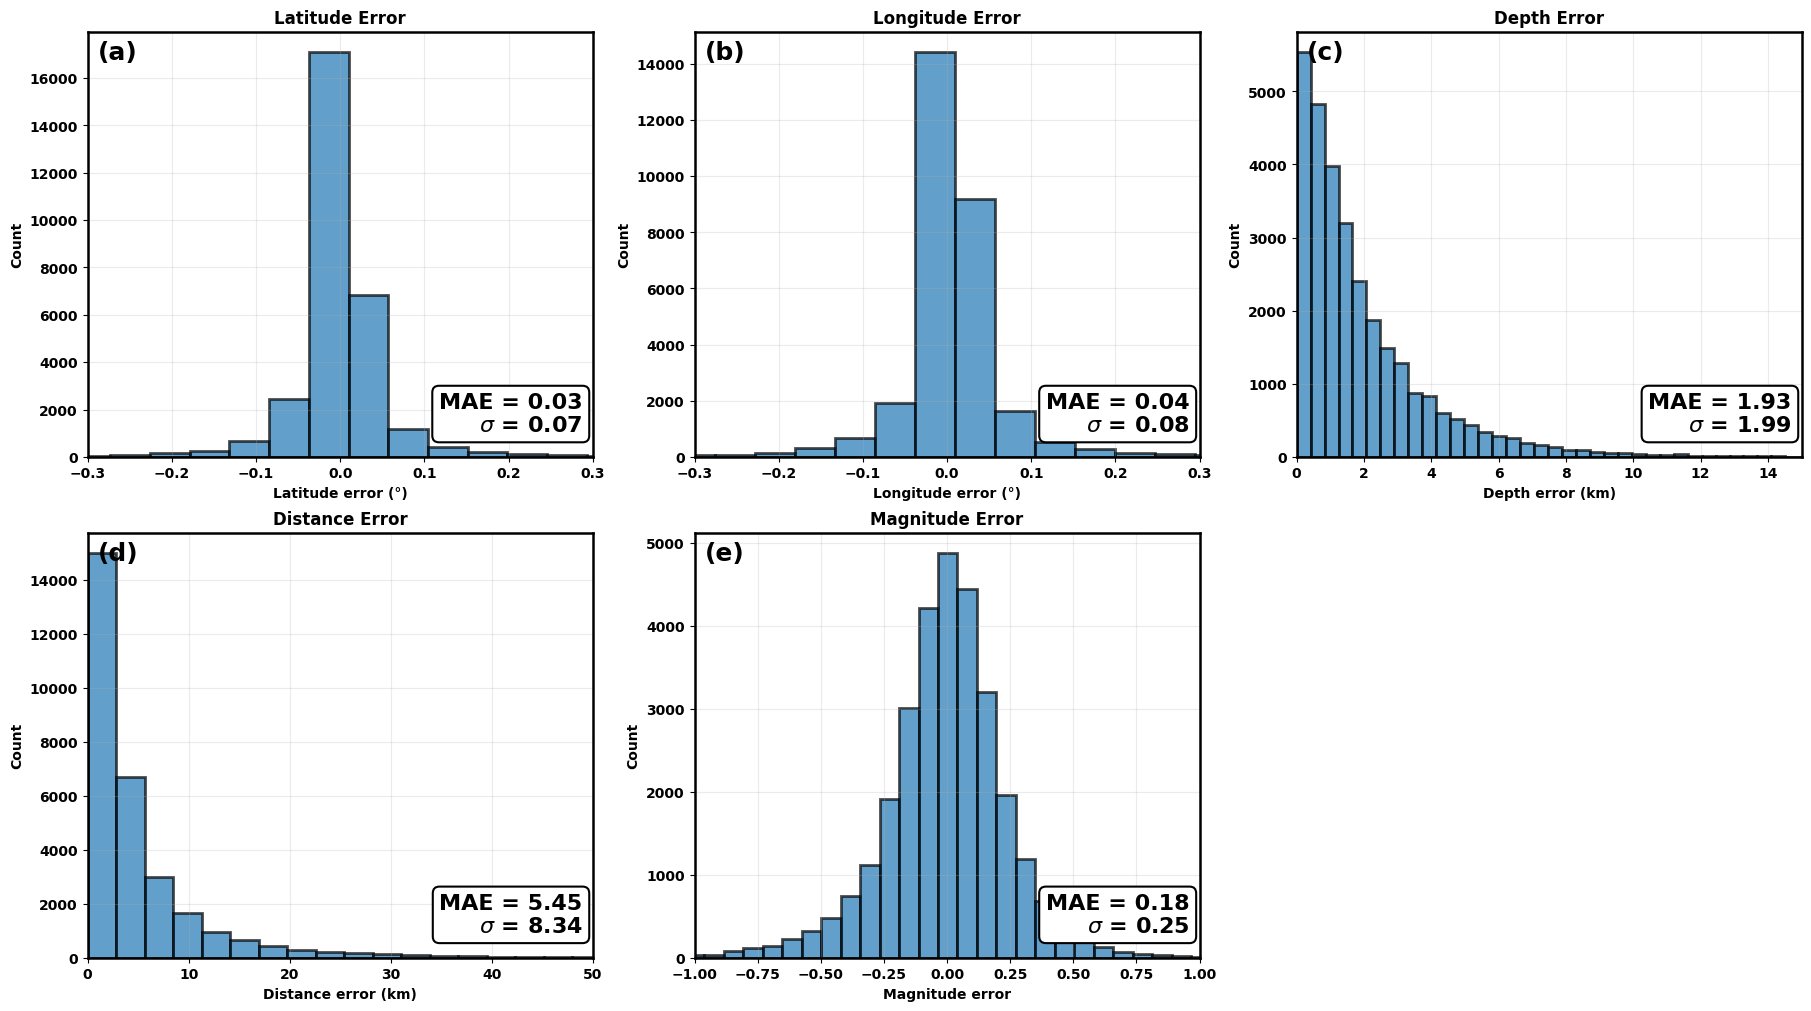

In [11]:
# =============================================================================
# Plot Error Histograms for Source-Parameter Estimation
# =============================================================================
#
# This section visualizes the prediction errors for earthquake source
# parameters using histogram plots. The displayed errors include
# latitude, longitude, depth, epicentral distance, and magnitude.
#
# Each panel reports the mean absolute error (MAE) and standard deviation
# of the corresponding error distribution.
# =============================================================================

# -----------------------------------------------------------------------------
# Prepare error distributions
# -----------------------------------------------------------------------------

lat_error = estimated_lat - true_lat
lon_error = estimated_long - true_long
depth_error = np.abs(predict_depth - true_depth)
distance_error = distall
magnitude_error = predict_mag - true_mag

errors = {
    "Latitude": lat_error,
    "Longitude": lon_error,
    "Depth": depth_error,
    "Distance": distance_error,
    "Magnitude": magnitude_error,
}

# -----------------------------------------------------------------------------
# Plot settings
# -----------------------------------------------------------------------------

FIGSIZE = (18, 10)
FONTSIZE = 18

columns = [
    ("Latitude", "Latitude Error", "Latitude error (°)"),
    ("Longitude", "Longitude Error", "Longitude error (°)"),
    ("Depth", "Depth Error", "Depth error (km)"),
    ("Distance", "Distance Error", "Distance error (km)"),
    ("Magnitude", "Magnitude Error", "Magnitude error"),
]

bins = {
    "Latitude": 60,
    "Longitude": 60,
    "Depth": 60,
    "Distance": 60,
    "Magnitude": 60,
}

xlims = {
    "Latitude": (-0.3, 0.3),
    "Longitude": (-0.3, 0.3),
    "Depth": (0, 15),
    "Distance": (0, 50),
    "Magnitude": (-1, 1),
}

# -----------------------------------------------------------------------------
# Create figure
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=FIGSIZE, constrained_layout=True)
ax = ax.flatten()

letters = [f"({chr(97+i)})" for i in range(len(columns))]

for i, (key, title, xlabel) in enumerate(columns):

    a = ax[i]
    data = errors[key]

    a.hist(
        data,
        bins=bins[key],
        edgecolor="black",
        linewidth=2.0,
        alpha=0.7
    )

    a.set_xlim(xlims[key])
    a.grid(alpha=0.25)

    # Panel title
    a.set_title(title, fontweight="bold")

    # Axis labels
    a.set_xlabel(xlabel, fontweight="bold")
    a.set_ylabel("Count", fontweight="bold")

    # Make tick labels bold
    for tick in a.get_xticklabels():
        tick.set_fontweight("bold")

    for tick in a.get_yticklabels():
        tick.set_fontweight("bold")

    # Panel letter
    a.text(
        0.02,
        0.98,
        letters[i],
        transform=a.transAxes,
        fontweight="bold",
        fontsize=FONTSIZE,
        va="top"
    )

    # Statistics box
    mae = np.mean(np.abs(data))
    sigma = np.std(data)

    a.text(
        0.98,
        0.05,
        f"MAE = {mae:.2f}\n$\\sigma$ = {sigma:.2f}",
        transform=a.transAxes,
        ha="right",
        va="bottom",
        fontsize=FONTSIZE - 2,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            linewidth=1.5
        )
    )

    # Thick plot borders
    for spine in a.spines.values():
        spine.set_linewidth(1.8)

# Remove unused panel
fig.delaxes(ax[-1])

plt.show()